# Week 5 Day 5 — Save Signal Panel

Produce `data/processed/signal_panel.parquet` — the file Week 6 will read directly.

It is identical to `richness_signal.parquet` plus one extra column:

| column | meaning |
|---|---|
| `direction` | +1 (cheap/buy), −1 (rich/sell), 0 (no signal) |

Week 6 reads this file, filters to `direction != 0` each day, ranks by `|z_score|`, and selects the top-N positions.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from termstructure.signals.richness import build_signal_panel

## 1. Build and save

In [2]:
panel = build_signal_panel(entry_z=2.0)
print(f"\nColumns : {list(panel.columns)}")
print(f"Shape   : {panel.shape}")
print(f"Dates   : {panel['date'].min().date()} -> {panel['date'].max().date()}")
panel.head(10)

Saved 99,190 rows across 13,286 dates -> C:\Users\aarna\Documents\termstructure\data\processed\signal_panel.parquet
Entry threshold : |z| > 2.0
Long signals    : 4,696  (4.7%)
Short signals   : 4,765  (4.8%)

Columns : ['date', 'maturity', 'residual_bps', 'rolling_mean', 'rolling_std', 'z_score', 'direction']
Shape   : (99190, 7)
Dates   : 1971-09-27 -> 2024-12-31


,date,maturity,residual_bps,rolling_mean,rolling_std,z_score,direction
0,1971-09-27,1,-0.003354,-0.003218,0.001376,-0.098744,0
1,1971-09-27,2,0.084717,0.082160,0.021180,0.120729,0
2,1971-09-27,3,-0.268919,-0.266860,0.022738,-0.090524,0
3,1971-09-27,5,0.227000,0.235977,0.032343,-0.277539,0
4,1971-09-27,7,0.430157,0.425140,0.021975,0.228284,0
5,1971-09-27,10,-0.172918,-0.180215,0.061907,0.117879,0
6,1971-09-28,1,-0.003539,-0.003228,0.001355,-0.229069,0
7,1971-09-28,2,0.081781,0.082148,0.020825,-0.017631,0
8,1971-09-28,3,-0.261498,-0.266687,0.022377,0.231907,0
9,1971-09-28,5,0.220275,0.235470,0.031924,-0.475994,0


## 2. Schema check

Confirm no nulls, correct dtypes, and `direction` is encoded correctly.

In [3]:
print("Dtypes:")
print(panel.dtypes)
print("\nNull counts:")
print(panel.isnull().sum())
print("\nDirection value counts:")
print(panel['direction'].value_counts().sort_index())

Dtypes:
date            datetime64[us]
maturity                 int64
residual_bps           float64
rolling_mean           float64
rolling_std            float64
z_score                float64
direction                int64
dtype: object

Null counts:
date            0
maturity        0
residual_bps    0
rolling_mean    0
rolling_std     0
z_score         0
direction       0
dtype: int64

Direction value counts:
direction
-1     4765
 0    89729
 1     4696
Name: count, dtype: int64


## 3. Signal activity heatmap

How many signal observations fired each year at each maturity?  
This lets us spot years where the signal was unusually active (2008, 2020) vs. quiet.

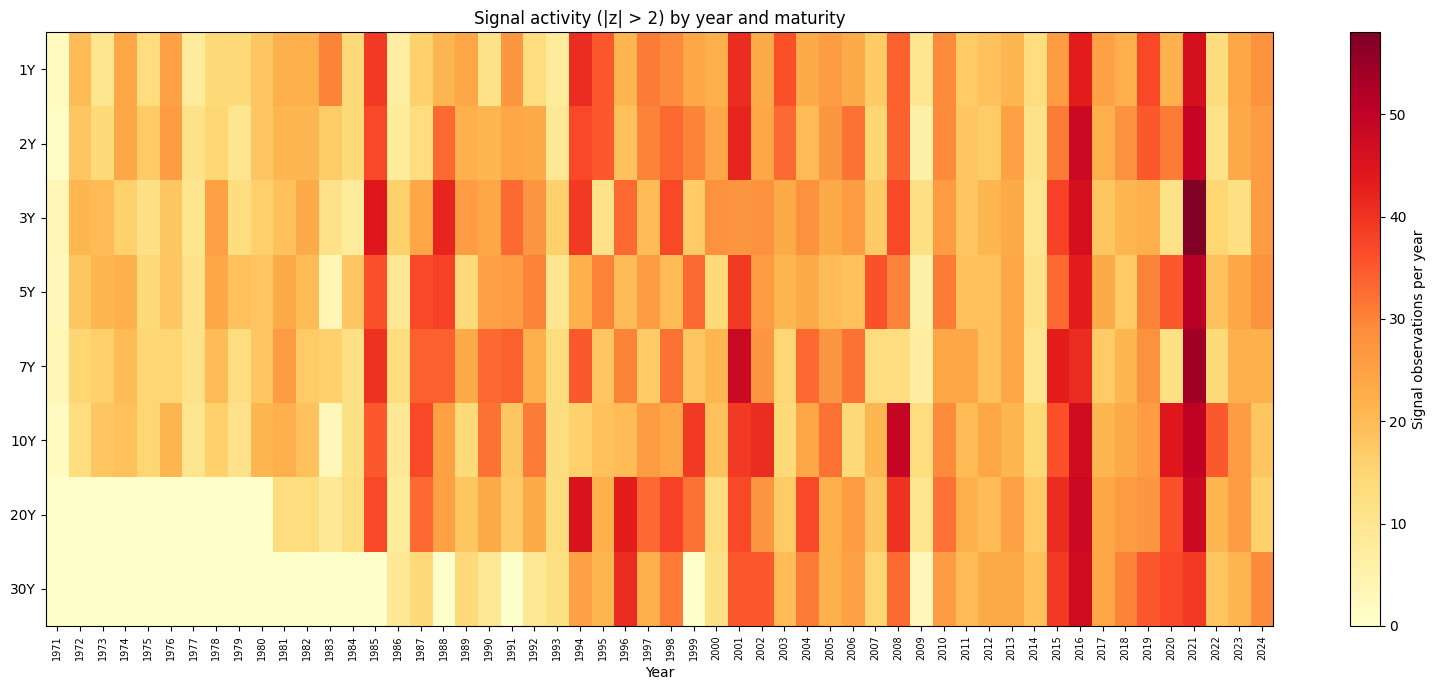

In [4]:
active = panel[panel['direction'] != 0].copy()
active['year'] = active['date'].dt.year

heat = (
    active.groupby(['year', 'maturity'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(heat.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Signal observations per year')

ax.set_yticks(range(len(heat.columns)))
ax.set_yticklabels([f'{m}Y' for m in heat.columns])
ax.set_xticks(range(len(heat.index)))
ax.set_xticklabels(heat.index, rotation=90, fontsize=7)
ax.set_xlabel('Year')
ax.set_title('Signal activity (|z| > 2) by year and maturity')

plt.tight_layout()
plt.savefig('data/week5_day5_signal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Simulate a Week 6 query

Show exactly what Week 6's portfolio construction will do with this file on a typical date:  
load the panel, filter to one date, rank by `|z_score|`, take top-3 cheap and top-3 rich.

In [5]:
# Week 6 will do exactly this pattern every day
def get_signals_for_date(panel: pd.DataFrame, date: str, top_n: int = 5):
    day = panel[panel['date'] == pd.Timestamp(date)].copy()
    cheap = day[day['direction'] ==  1].nlargest(top_n, 'z_score')
    rich  = day[day['direction'] == -1].nsmallest(top_n, 'z_score')
    return cheap, rich

# Pick a recent date that likely has signals
signal_dates = panel[panel['direction'] != 0]['date'].unique()
example_date = pd.Timestamp(signal_dates[-50])   # 50th from end → not the very last day

cheap, rich = get_signals_for_date(panel, example_date)

print(f"Date: {example_date.date()}\n")
print("=== BUY (cheap) positions ===")
print(cheap[['maturity', 'residual_bps', 'z_score', 'direction']].to_string(index=False))
print("\n=== SELL (rich) positions ===")
print(rich[['maturity', 'residual_bps', 'z_score', 'direction']].to_string(index=False))

Date: 2024-04-17

=== BUY (cheap) positions ===
 maturity  residual_bps  z_score  direction
       20      3.612716 3.612579          1

=== SELL (rich) positions ===
 maturity  residual_bps   z_score  direction
        7     -0.596907 -2.626881         -1
       30    -12.700354 -2.602834         -1


## 5. Coverage by year

Count of trading days with at least one signal per year. Years with zero coverage are calendar gaps in the raw data (pre-1971 or holidays), not bugs.

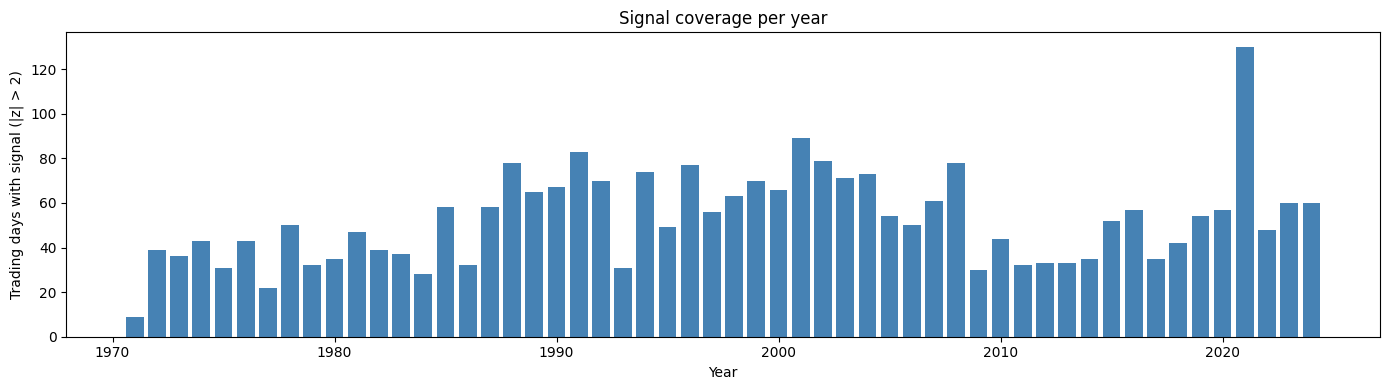

date
1971      9
1972     39
1973     36
1974     43
1975     31
1976     43
1977     22
1978     50
1979     32
1980     35
1981     47
1982     39
1983     37
1984     28
1985     58
1986     32
1987     58
1988     78
1989     65
1990     67
1991     83
1992     70
1993     31
1994     74
1995     49
1996     77
1997     56
1998     63
1999     70
2000     66
2001     89
2002     79
2003     71
2004     73
2005     54
2006     50
2007     61
2008     78
2009     30
2010     44
2011     32
2012     33
2013     33
2014     35
2015     52
2016     57
2017     35
2018     42
2019     54
2020     57
2021    130
2022     48
2023     60
2024     60


In [6]:
coverage = (
    panel[panel['direction'] != 0]
    .groupby(panel['date'].dt.year)['date']
    .nunique()
    .rename('signal_days')
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(coverage.index, coverage.values, color='steelblue', width=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Trading days with signal (|z| > 2)')
ax.set_title('Signal coverage per year')
plt.tight_layout()
plt.savefig('data/week5_day5_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print(coverage.to_string())

## Week 5 complete ✓

All five outputs are on disk:

| file | created | description |
|---|---|---|
| `bond_residuals.parquet` | Day 1 | demeaned residuals, outliers removed |
| `residual_means.parquet` | Day 1 | per-maturity demeaning constants |
| `richness_signal.parquet` | Day 3 | z-scores (rolling 60d window) |
| `signal_panel.parquet` | Day 5 | same + `direction` column, backtest-ready |

Week 6 entry point: `pd.read_parquet('data/processed/signal_panel.parquet')`